# Evaluating continuity equation for mass conservation

Since the mass density is found to be constant on both short and long timescales, we have that mass is propotional to the cell volume:

$M = \rho_m V = \rho_m\int_A h(x,y)~dA$.

$m(x,y) =  \rho_m \cdot h(x,y)$

In a monolayer, the continuity equation then takes the form:


$\frac{dM}{d t} + \oint_{\partial A} m(x,y)(\vec{v}\cdot\hat{n})dL = \Sigma$

$\rho_m\frac{d}{d t}\int_A h(x,y) dA + \rho_m\oint_{\partial A} h(x,y)(\vec{v}\cdot\hat{n})dL = \Sigma$

In [7]:
import os
import sys
import json
import imageio
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.signal import convolve2d
from scipy.signal import fftconvolve, correlate
from scipy.ndimage import gaussian_filter
from skimage.morphology import disk


sys.path.append("scripts/utils/")
from file_operations import *
from Microscopes import Holomonitor, Tomocube
from SegmentedCells import SegmentedCells
from averaging_functions import compute_pdf_from_bins

sys.path.append("scripts/analysis/")
from mass_conservation import *

data_path = "../../../../hdd_data/silja/Monolayers/"

### Load data

In [6]:
# Parameters
microscope = Tomocube()
frame      = 21 #29, 32, 36
# pix_to_um  = get_voxel_size_35mm()
# frame_to_h = 1 / 4
# h_scale    = 1000
# n_scale    = 10_000

In [30]:
frame = 0
# Load data
h_fname = "MDCK-li_height"
n_fname = "MDCK-li_refractive_index"
dataset  = "MDCK_20250904_B1-1"
cellprop = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")

# load heights
h_full = np.array([imageio.v2.imread(f"{data_path}/height_fields/calibrated/{dataset}/{h_fname}_{frame}.tiff"),
                   imageio.v2.imread(f"{data_path}/height_fields/calibrated/{dataset}/{h_fname}_{frame+1}.tiff")])
# refractive
n_full = np.array([imageio.v2.imread(f"{data_path}/ri_fields/calibrated/{dataset}/{n_fname}_{frame}.tiff"),
                   imageio.v2.imread(f"{data_path}/ri_fields/calibrated/{dataset}/{n_fname}_{frame+1}.tiff")])


# transform to µm
h_full = h_full * microscope.pix_to_um * microscope.h_to_um    # µm
n_full = n_full * microscope.ri_conversion

mass_density_full = h_full * (n_full - microscope.n0) / (np.mean(n_full)- microscope.n0)    # µm
mass_density_growth = np.diff(mass_density_full.mean(axis=(1,2)))

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20250904_B1-1_cells.p.


### Plot segmented parameters to inform PIV choices

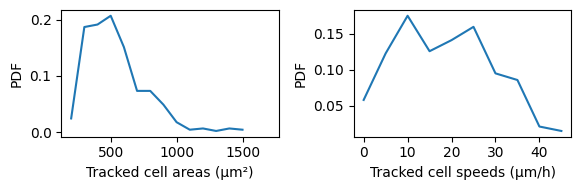

In [31]:
# get cell properties
mean_area = np.ma.mean(cellprop.A[frame-1])
mean_mass = np.ma.mean(cellprop.A[frame-1] * cellprop.h[frame-1] * cellprop.n[frame-1])

track_speed = np.ma.sqrt(cellprop.dx[frame-1]**2 + cellprop.dy[frame-1]**2) / microscope.frame_to_h
track_speed = track_speed.compressed()
track_speed = compute_pdf_from_bins(track_speed, scale_to_int=0.2)

track_areas = cellprop.A[frame-1].compressed()
track_areas = compute_pdf_from_bins(track_areas, scale_to_int=0.01)

fig, ax = plt.subplots(1,2, figsize=(6,2))

ax[0].plot(track_areas[0], track_areas[1])
ax[1].plot(track_speed[0], track_speed[1])
ax[0].set(xlabel="Tracked cell areas (µm²)",
          ylabel="PDF");
ax[1].set(xlabel="Tracked cell speeds (µm/h)",
          ylabel="PDF");
fig.tight_layout()

In [32]:
# determine PIV parameters
dt    = microscope.frame_to_h                          # period between frames
dcell = np.sqrt(mean_area) / microscope.pix_to_um      # average cell diameter (pix)
vmax  = 30                                  # max speed in µm / h
dmax  = vmax * dt / microscope.pix_to_um            # max displacement in pix / frame

WSmax = 4 * dmax                            # min size of largest window. 1/4 of mas displacement
WSmin = dcell                               # min size of smallest windos. ~ 1 cell diameter

print(f"Largest  interrogation window should be >= {int(WSmax)}")
print(f"Smallest interrogation window should be >= {int(WSmin)}")

Largest  interrogation window should be >= 193
Smallest interrogation window should be >= 156


### Load PIV velocities and compare to tracked velocities

Holomonitor does not get good PIV speed distribution.

75% overlap between window is good

Processing:
- Mask outside regions
- Remove background
- remove low correlation velocities

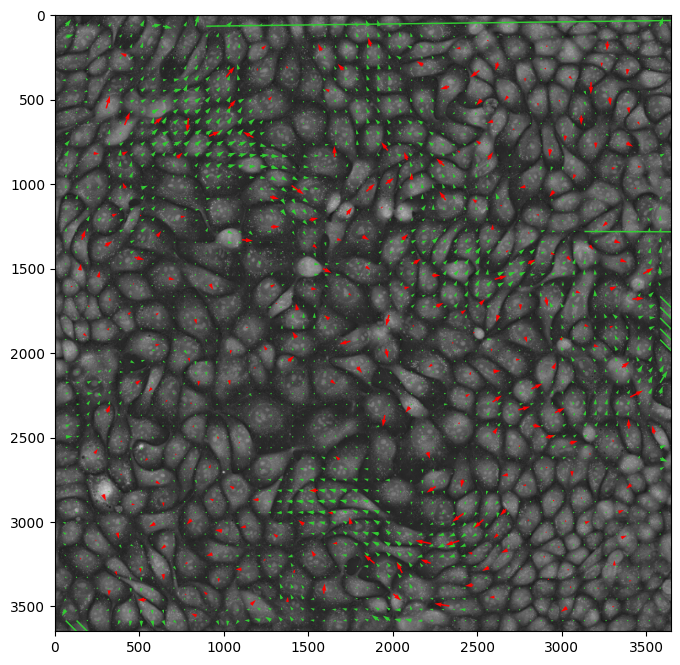

In [33]:
# Load PIV. Unit?
PIV_path = f"{data_path}piv/{dataset}/PIV_256_128/"
vec_position, vec_velocity = import_PIV_frame(PIV_path, frame=frame)

# Compute size of grid 
nx = len(np.unique(vec_position[0]))
ny = len(np.unique(vec_position[1]))
dn = vec_position[1][1] - vec_position[1][0]

# Transform PIV input to matrices. Dimensions are given by PIV txt
X = np.array(vec_position[0]).reshape(nx, ny).T-1
Y = np.array(vec_position[1]).reshape(nx, ny).T-1
U = np.array(vec_velocity[0]).reshape(nx, ny).T * microscope.pix_to_um / microscope.frame_to_h
V = np.array(vec_velocity[1]).reshape(nx, ny).T * microscope.pix_to_um / microscope.frame_to_h

Xt = cellprop.x[frame] / microscope.pix_to_um
Yt = cellprop.y[frame] / microscope.pix_to_um
Ut = cellprop.dx[frame] / microscope.frame_to_h
Vt = cellprop.dy[frame] / microscope.frame_to_h

fig, ax = plt.subplots(1,1, figsize=(8,8))
im = ax.imshow(n_full[0], cmap="gray", origin="lower")
ax.quiver(X,  Y,  U,  -V,  color="limegreen")
ax.quiver(Xt, Yt, Ut, -Vt, color="r")
ax.invert_yaxis()

### Remove spurious velocities

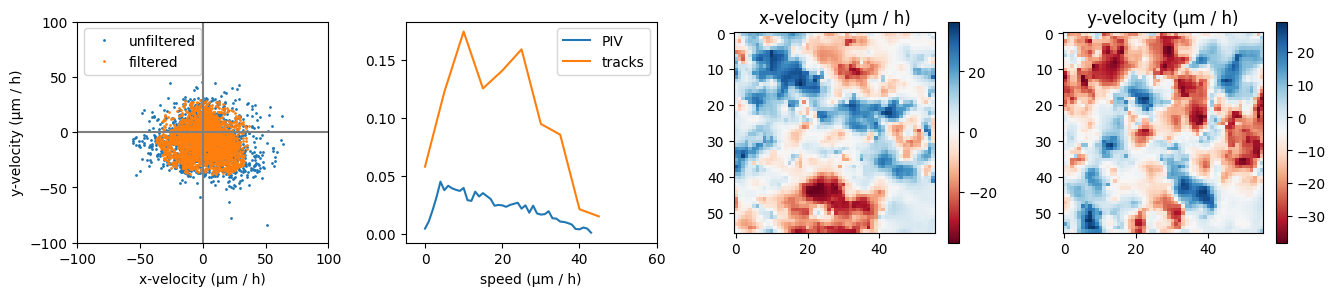

In [34]:
U_filtered, V_filtered = filter_velocity_fields(X, Y, U, V, speed_limit=40, sigma=0.5)

# Compute speed distributions
speed = np.ma.sqrt(U_filtered**2 + V_filtered**2)
PIV_speed = compute_pdf_from_bins(speed.ravel(), scale_to_int=1)

# Plot image
fig, axes = plt.subplots(1,4, figsize=(13.5,3))

axes[0].plot(U.ravel(), V.ravel(), '.', ms=2, label="unfiltered")
axes[0].plot(U_filtered.ravel(), V_filtered.ravel(), '.', ms=2, label="filtered")
axes[0].axvline(0, c="gray")
axes[0].axhline(0, c="gray")

axes[1].plot(PIV_speed[0],   PIV_speed[1], '-', label="PIV")
axes[1].plot(track_speed[0], track_speed[1], '-', label="tracks")
axes[0].legend()
axes[1].legend()

for v, ax in zip([U_filtered, V_filtered], axes[2:]):
    im = ax.imshow(v, cmap="RdBu")
    fig.colorbar(im, ax=ax)

axes[0].set(xlabel="x-velocity (µm / h)", 
            ylabel="y-velocity (µm / h)")
axes[1].set(xlabel="speed (µm / h)")
axes[2].set(title="x-velocity (µm / h)")
axes[3].set(title="y-velocity (µm / h)")

axes[0].set(ylim=(-100, 100), xlim=(-100, 100))
axes[1].set(xlim=(-5, 60))
fig.tight_layout()

### Match mass images with velocity fields

In [35]:
# define parameters
velocity_scale = 1#np.mean(track_speed) / np.mean(PIV_speed)
piv_step_size  = 64

mass_flux_pixel = finite_volume_mass_flux(mass_density_full[0], U_filtered, V_filtered,
                                         pix_to_um=microscope.pix_to_um, 
                                         piv_step_size=piv_step_size,
                                         velocity_scale=velocity_scale)

mass_change_pixel = finite_volume_mass_change(mass_density_full,
                                        pix_to_um=microscope.pix_to_um,
                                        piv_step_size=piv_step_size,
                                        dt=dt)


mass_density = downsample_field(mass_density_full[0])

divergence = compute_divergence(U_filtered, V_filtered, 
                                pix_to_um=microscope.pix_to_um, 
                                piv_step_size=piv_step_size,
                                velocity_scale=velocity_scale)

### Compute mass change

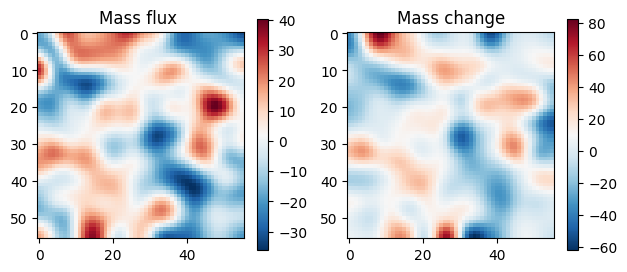

In [45]:
sigma = 3

smooth_flux   = gaussian_filter(mass_flux_pixel,   sigma)
smooth_change = gaussian_filter(mass_change_pixel, sigma)

fig, ax = plt.subplots(1,2, figsize=(11*2/3,3))
im0 = ax[0].imshow(smooth_flux,   cmap="RdBu_r")#, vmin=-200, vmax=200, extent=[0,567,567,0])
im1 = ax[1].imshow(smooth_change, cmap="RdBu_r")#, vmin=-200, vmax=200, extent=[0,567,567,0])
# im2 = ax[2].imshow(mass_density)#, cmap="RdBu_r", extent=[0,567,567,0], vmin=-200, vmax=200)

fig.colorbar(im0, ax=ax[0])
fig.colorbar(im1, ax=ax[1])
# fig.colorbar(im2, ax=ax[2])

ax[0].set(title="Mass flux ")
ax[1].set(title="Mass change");